In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [67]:
# read all words 
words = open('names.txt', 'r').read().splitlines()
words[:8]
g = torch.Generator().manual_seed(2147483647)

In [4]:
# build vocabulary of chars and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(stoi)
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [92]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one
X, Y = [], [] # x are in inputs to the NN, y are the labels for each example inside x    

for w in words:
    #print(w)
    context = [0] * block_size
    #print(f'{context=}')
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
        #print(f'{context=}')

X = torch.tensor(X)
Y = torch.tensor(Y)

In [93]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [68]:
C = torch.randn((27 ,2), generator=g)

In [69]:
C[5]

tensor([-0.4713,  0.7868])

In [30]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C
# same result. just for demonstration. 
# but this means we can just use the C[5] as its much faster

tensor([1.3134, 0.6365])

In [33]:
C[torch.tensor([5,6,7,7,7,7])]

tensor([[ 1.3134,  0.6365],
        [-1.1716,  0.9701],
        [ 0.6579, -0.2804],
        [ 0.6579, -0.2804],
        [ 0.6579, -0.2804],
        [ 0.6579, -0.2804]])

In [70]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [39]:
W1 = torch.rand((6, 100)) # inputs = 6, we have 2d embedding and we have 3 of them. and lets create 100 neurons for example.
b1 = torch.randn(100)
#ideally we would like to do something like this, but this won't work.
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [42]:
# one of the ways to do this in torch is to use concatenate
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [44]:
# above is ugly and not scalable, so we could also do something like this -
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [45]:
#even better way to do it, for ex
emb.shape

torch.Size([32, 3, 2])

In [46]:
emb.view(32, 6)

tensor([[ 1.1569,  1.2673,  1.1569,  1.2673,  1.1569,  1.2673],
        [ 1.1569,  1.2673,  1.1569,  1.2673,  1.3134,  0.6365],
        [ 1.1569,  1.2673,  1.3134,  0.6365, -0.5958,  1.2658],
        [ 1.3134,  0.6365, -0.5958,  1.2658, -0.5958,  1.2658],
        [-0.5958,  1.2658, -0.5958,  1.2658,  0.4728, -2.6602],
        [ 1.1569,  1.2673,  1.1569,  1.2673,  1.1569,  1.2673],
        [ 1.1569,  1.2673,  1.1569,  1.2673,  0.9100, -1.2850],
        [ 1.1569,  1.2673,  0.9100, -1.2850, -1.0420,  2.0939],
        [ 0.9100, -1.2850, -1.0420,  2.0939, -0.4186,  0.4295],
        [-1.0420,  2.0939, -0.4186,  0.4295, -0.1206, -0.8704],
        [-0.4186,  0.4295, -0.1206, -0.8704, -0.4186,  0.4295],
        [-0.1206, -0.8704, -0.4186,  0.4295,  0.4728, -2.6602],
        [ 1.1569,  1.2673,  1.1569,  1.2673,  1.1569,  1.2673],
        [ 1.1569,  1.2673,  1.1569,  1.2673,  0.4728, -2.6602],
        [ 1.1569,  1.2673,  0.4728, -2.6602, -0.1206, -0.8704],
        [ 0.4728, -2.6602, -0.1206, -0.8

In [71]:
#hidden layer
W1 = torch.rand((6, 100), generator=g) # inputs = 6, we have 2d embedding and we have 3 of them. and lets create 100 neurons for example.
b1 = torch.randn(100, generator=g)

In [72]:
# now we can do this easily
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # -1 makes python derive what this should be
h

tensor([[ 0.8617,  0.9913,  0.9757,  ..., -0.5181,  0.9876,  0.9743],
        [ 0.7252,  0.9894,  0.9387,  ..., -0.5301,  0.7227,  0.8225],
        [ 0.9836,  0.9837,  0.9909,  ...,  0.0625,  0.9979,  0.9836],
        ...,
        [ 0.9397, -0.3916, -0.4198,  ...,  0.5430,  0.9894,  0.2138],
        [-0.5801,  0.7284, -0.8813,  ..., -0.6073,  0.7667, -0.1378],
        [-0.1500,  0.5625, -0.4973,  ..., -0.9955, -0.8960, -0.8921]])

In [51]:
h.shape

torch.Size([32, 100])

In [52]:
# always make sure the broadcasting is happening as you think it should
(emb.view(-1, 6) @ W1).shape

torch.Size([32, 100])

In [53]:
b1.shape

torch.Size([100])

In [54]:
# 32, 100
#  1, 100

In [73]:
W2 = torch.rand((100, 27), generator=g) # input 100, output 27 cause we have 27 possible chars that can come out
b2 = torch.randn(27, generator=g)

In [74]:
# output of the NN
logits = h @ W2 + b2

In [58]:
logits.shape

torch.Size([32, 27])

In [75]:
# like before 
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)

In [60]:
prob.shape

torch.Size([32, 27])

In [61]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [77]:
#What probability did the network assign to the correct answer for each example?
#prob[torch.arange(32), Y]
# negative loss likelihood
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(7.1889)

In [191]:
#putting everything together so far 
# dataset
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [203]:
# initialize parameters
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [204]:
# number of parameters in total
sum(p.nelement() for p in parameters)

3481

In [205]:
for p in parameters: 
    p.requires_grad = True

In [199]:
for _ in range(10):
    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32, ))
    # forward pass
    emb = C[X[ix]]  # (32, 3, 2) # X[ix] to only grab those mini batch rows instead of the entire X
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    # same as above 3, more efficient in pytorch
    loss = F.cross_entropy(logits, Y[ix]) # results also should be of the mini batch
    #print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

9.030571937561035


In [124]:
# For the entire data set
emb = C[X]  # (32, 3, 2) 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(3.1628, grad_fn=<NllLossBackward0>)

In [105]:
# notice that the takes some time as we are doing the forward pass and the backward pass on the entire dataset
# in practice - we do this on mini batches of data
# randomly select a mini batch and iterate on that
# this creates int that index into our dataset
# we can put this in our method
torch.randint(0, X.shape[0], (32, ))
# cause of the mini batches, the quality of our gradient is lower
# but its much better to have an approx gradient and just make more steps, than evaluate exact gradient and take fewer steps

tensor([207472,  71029,  68200, 131466, 183530,   5556, 176840,  44916, 143417,
        223708,  88258,  50978, 187888,  48814, 111541,  15787,  55663,  25858,
        208935,  91098,  71155, 219615, 114658,  75342, 135600,  60069, 194000,
        216382, 155343,  76751,  11902, 171088])

In [181]:
# to figure out the right learning rate 
lre = torch.linspace(-3, 0, 1000) # learning rate exponent
lrs = 10**lre

In [186]:
#for tracking
lri = []
lossi = []

for i in range(1000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32, ))
    # forward pass
    emb = C[X[ix]]  # (32, 3, 2) # X[ix] to only grab those mini batch rows instead of the entire X
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Y[ix]) # results also should be of the mini batch
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.0001
    for p in parameters:
        p.data += -lr * p.grad

    # track status
    lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

8.344609260559082


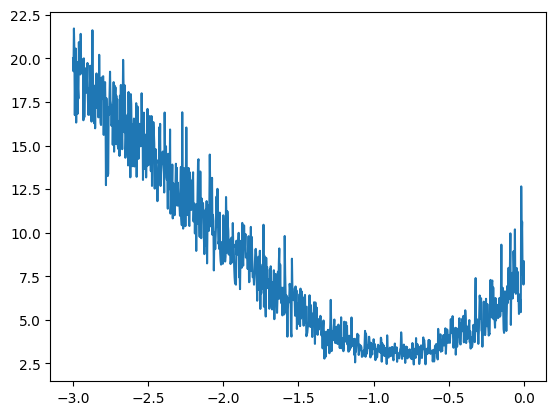

In [187]:
plt.plot(lri, lossi)

In [206]:
# traing split, dev/validation split, test split
# 80%, 10%, 10%
def build_dataset(words):
    # build the dataset
    block_size = 3 # context length: how many characters do we take to predict the next one
    X, Y = [], [] # x are in inputs to the NN, y are the labels for each example inside x    

    for w in words:
        #print(w)
        context = [0] * block_size
        #print(f'{context=}')
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
            #print(f'{context=}')
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [209]:
# not training on the training data 

for i in range(10000):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2) # X[ix] to only grab those mini batch rows instead of the entire X
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # results also should be of the mini batch
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(loss.item())

2.381876230239868


In [210]:
# for evaluation
emb = C[Xdev]  # (32, 3, 2) 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3550, grad_fn=<NllLossBackward0>)

In [211]:
emb = C[Xtr]  # (32, 3, 2) 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3360, grad_fn=<NllLossBackward0>)

In [212]:
# now to increase the power of the model, we expect to make performance improvement by scaling up the size of this NN
# initialize parameters, upgrade hidden layer from 100 to 300
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [213]:
sum(p.nelement() for p in parameters)

10281

In [214]:
for p in parameters: 
    p.requires_grad = True

In [228]:
lri = []
lossi = []
stepi = []

for i in range(30000):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2) # X[ix] to only grab those mini batch rows instead of the entire X
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # results also should be of the mini batch
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    stepi.append(i)
    lossi.append(loss.item())

print(loss.item())

2.0025241374969482


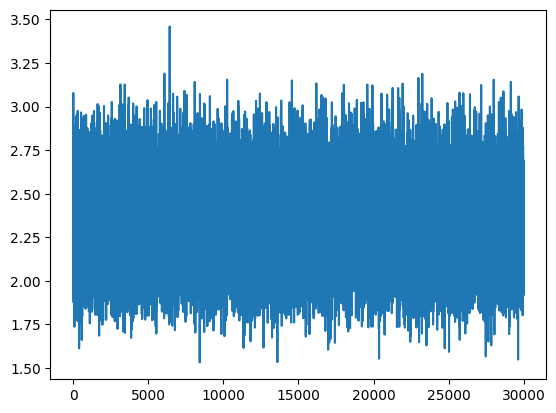

In [223]:
plt.plot(stepi, lossi)

In [229]:
# for evaluation
emb = C[Xdev]  # (32, 3, 2) 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2571, grad_fn=<NllLossBackward0>)

In [230]:
emb = C[Xtr]  # (32, 3, 2) 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2309, grad_fn=<NllLossBackward0>)

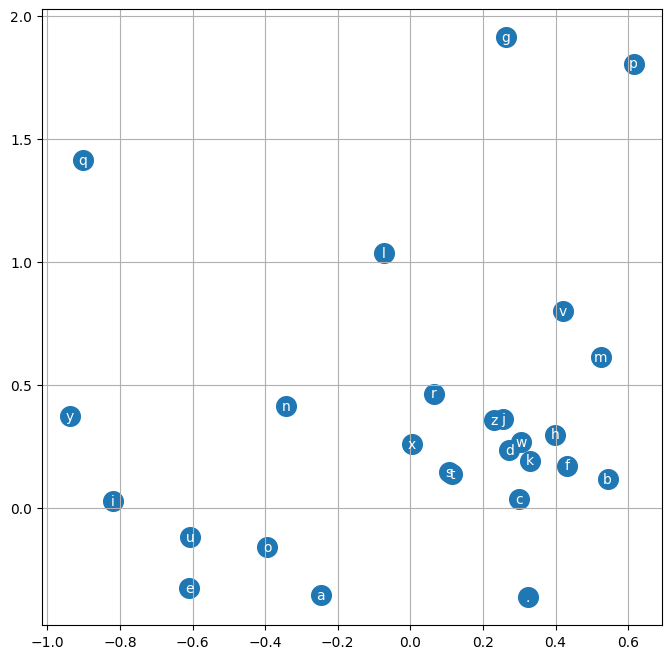

In [231]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [232]:
# increasing the hidden layer did not help much with performance
# so now we think that the contraint might be the embedding vectors which are currently 2
# initialize parameters, C improved 2 dimension to 10
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [233]:
sum(p.nelement() for p in parameters)

11897

In [234]:
for p in parameters: 
    p.requires_grad = True

In [235]:
lri = []
lossi = []
stepi = []

In [244]:
for i in range(50000):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2) # X[ix] to only grab those mini batch rows instead of the entire X
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) # results also should be of the mini batch
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.040778160095215


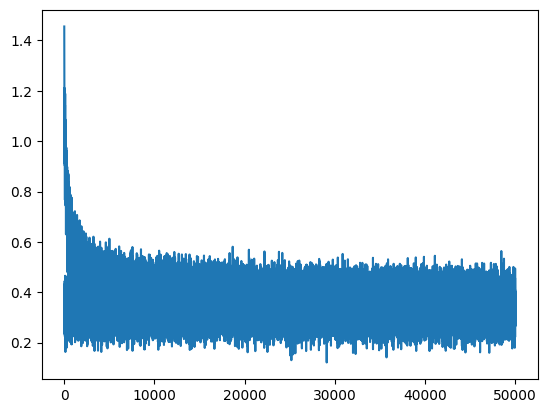

In [245]:
plt.plot(stepi, lossi)

In [246]:
# for evaluation
emb = C[Xdev]  # (32, 3, 2) 
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2250, grad_fn=<NllLossBackward0>)

In [247]:
emb = C[Xtr]  # (32, 3, 2) 
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1749, grad_fn=<NllLossBackward0>)

In [248]:
# sample from the model 
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # init with all ...
    while True:
        emb = C[torch.tensor([context])] # 1, block_size, d
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carpahf.
abbil.
khismili.
taty.
salaysa.
jazonte.
amerynchianni.
nellaiah.
maiivon.
leigh.
ham.
por.
desinn.
salin.
alianni.
wazeloniearynix.
kae.
pinslee.
dae.
oia.
